In [1]:
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import random
import numpy as np

In [3]:
class TinyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, 3, padding=1)
        self.fc1   = nn.Linear(16 * 7 * 7, 64)
        self.fc2   = nn.Linear(64, 10)
        self.pool  = nn.MaxPool2d(2)
        self.relu  = nn.ReLU()
 
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

In [4]:
def set_seed(seed):
    """Makes the run reproducible AND ensures each seed actually differs."""
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)
 

In [5]:

def evaluate(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            output = model(images)
            _, predicted = torch.max(output, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total  # returns the number, doesn't just print

# Training Data

In [9]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])
train_data = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_data  = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [ ]:

SEEDS = [0, 42, 123]   # 3 seeds — drop to [0, 42] if time-constrained
 
for seed in SEEDS:
    print(f"\n=== Training seed {seed} ===")
    set_seed(seed)
 
    train_loader = DataLoader(train_data, batch_size=64, shuffle=True)  # reshuffled per seed
    model = TinyNet()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
 
    for epoch in range(5):
        total_loss = 0
        for images, labels in train_loader:
            optimizer.zero_grad()
            output = model(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"  Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f}")
 
    baseline_acc = evaluate(model, test_loader)
    print(f"  Seed {seed} baseline accuracy: {baseline_acc:.2f}%")
 
    torch.save(model.state_dict(), f'tinynet_fashion_seed{seed}.pth')
    print(f"  Saved: tinynet_fashion_seed{seed}.pth")


=== Training seed 0 ===
  Epoch 1 | Loss: 0.5217
  Epoch 2 | Loss: 0.3434
  Epoch 3 | Loss: 0.2980
  Epoch 4 | Loss: 0.2688
  Epoch 5 | Loss: 0.2507
  Seed 0 baseline accuracy: 89.62%
  Saved: tinynet_fashion_seed0.pth

=== Training seed 42 ===
  Epoch 1 | Loss: 0.5262
  Epoch 2 | Loss: 0.3487
  Epoch 3 | Loss: 0.3050
  Epoch 4 | Loss: 0.2760
  Epoch 5 | Loss: 0.2578
  Seed 42 baseline accuracy: 89.13%
  Saved: tinynet_fashion_seed42.pth

=== Training seed 123 ===
  Epoch 1 | Loss: 0.5196
  Epoch 2 | Loss: 0.3525
  Epoch 3 | Loss: 0.3089
  Epoch 4 | Loss: 0.2812
  Epoch 5 | Loss: 0.2589
  Seed 123 baseline accuracy: 89.32%
  Saved: tinynet_fashion_seed123.pth


# Sensitivity Sweep for sensitivy gap and layers analysis

In [7]:

SEEDS = [0, 42, 123]  

In [10]:

def load_fresh_model(seed):
    model = TinyNet()
    model.load_state_dict(torch.load(f'tinynet_fashion_seed{seed}.pth'))
    model.eval()
    return model
 
def prune_single_layer(model, layer_name, amount):
    layer = getattr(model, layer_name)
    prune.l1_unstructured(layer, name='weight', amount=amount)
    return model
 
# Sweep range — matches your original FashionMNIST full sweep checkpoints
#CHECKPOINTS = [0, 10, 20, 30, 40, 45, 50, 55, 60, 65, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80]
CHECKPOINTS = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80]
LAYERS = ['conv1', 'conv2', 'fc1', 'fc2']
 
results = {}  # results[seed][sparsity] = gap
 
for seed in SEEDS:
    print(f"\n=== Sensitivity sweep, seed {seed} ===")
    baseline_model = load_fresh_model(seed)
    baseline_acc = evaluate(baseline_model, test_loader)
 
    seed_gaps = {}
    for pct in CHECKPOINTS:
        amount = pct / 100
        layer_drops = {}
        for layer_name in LAYERS:
            m = load_fresh_model(seed)          # fresh reload — no carried-forward damage
            m = prune_single_layer(m, layer_name, amount)
            acc = evaluate(m, test_loader)
            drop = baseline_acc - acc
            layer_drops[layer_name] = drop
 
        gap = max(layer_drops.values()) - min(layer_drops.values())
        seed_gaps[pct] = gap
        print(f"  {pct}% sparsity | gap = {gap:.2f}pp | drops = {layer_drops}")
 
    results[seed] = seed_gaps


=== Sensitivity sweep, seed 0 ===
  0% sparsity | gap = 0.00pp | drops = {'conv1': 0.0, 'conv2': 0.0, 'fc1': 0.0, 'fc2': 0.0}
  5% sparsity | gap = 0.08pp | drops = {'conv1': -0.0899999999999892, 'conv2': -0.01999999999999602, 'fc1': -0.009999999999990905, 'fc2': -0.03999999999999204}
  10% sparsity | gap = 0.09pp | drops = {'conv1': -0.09999999999999432, 'conv2': -0.009999999999990905, 'fc1': -0.04999999999999716, 'fc2': -0.04999999999999716}
  15% sparsity | gap = 0.22pp | drops = {'conv1': 0.20000000000000284, 'conv2': 0.060000000000002274, 'fc1': -0.01999999999999602, 'fc2': 0.0}
  20% sparsity | gap = 0.50pp | drops = {'conv1': 0.3400000000000034, 'conv2': 0.10999999999999943, 'fc1': 0.010000000000005116, 'fc2': -0.1599999999999966}
  25% sparsity | gap = 0.44pp | drops = {'conv1': 0.3400000000000034, 'conv2': 0.030000000000001137, 'fc1': -0.09999999999999432, 'fc2': -0.030000000000001137}
  30% sparsity | gap = 0.85pp | drops = {'conv1': 0.7700000000000102, 'conv2': 0.1300000000

In [12]:

def prune_uniform(model, amount):
    prune.l1_unstructured(model.conv1, name='weight', amount=amount)
    prune.l1_unstructured(model.conv2, name='weight', amount=amount)
    prune.l1_unstructured(model.fc1,   name='weight', amount=amount)
    prune.l1_unstructured(model.fc2,   name='weight', amount=amount)
    return model

uniform_results = {}

for seed in SEEDS:
    print(f"\n=== Uniform pruning sweep, seed {seed} ===")
    seed_accs = {}
    for pct in CHECKPOINTS:
        amount = pct / 100
        m = load_fresh_model(seed)
        m = prune_uniform(m, amount)
        acc = evaluate(m, test_loader)
        seed_accs[pct] = acc
        print(f"  {pct}% sparsity | accuracy = {acc:.2f}%")
    uniform_results[seed] = seed_accs

print(f"\n\n=== SUMMARY: FashionMNIST accuracy under uniform pruning, across seeds ===")
print(f"{'Sparsity':>10}", end="")
for seed in SEEDS:
    print(f"{'seed'+str(seed):>12}", end="")
print()
for pct in CHECKPOINTS:
    print(f"{pct:>9}%", end="")
    for seed in SEEDS:
        print(f"{uniform_results[seed][pct]:>12.2f}", end="")
    print()


=== Uniform pruning sweep, seed 0 ===
  0% sparsity | accuracy = 89.62%
  5% sparsity | accuracy = 89.76%
  10% sparsity | accuracy = 89.81%
  15% sparsity | accuracy = 89.43%
  20% sparsity | accuracy = 89.24%
  25% sparsity | accuracy = 89.03%
  30% sparsity | accuracy = 88.46%
  35% sparsity | accuracy = 88.37%
  40% sparsity | accuracy = 87.62%
  45% sparsity | accuracy = 86.70%
  50% sparsity | accuracy = 84.82%
  55% sparsity | accuracy = 77.00%
  60% sparsity | accuracy = 70.73%
  65% sparsity | accuracy = 61.17%
  70% sparsity | accuracy = 42.90%
  71% sparsity | accuracy = 35.95%
  72% sparsity | accuracy = 20.91%
  73% sparsity | accuracy = 17.35%
  74% sparsity | accuracy = 17.26%
  75% sparsity | accuracy = 25.43%
  76% sparsity | accuracy = 21.80%
  77% sparsity | accuracy = 20.41%
  78% sparsity | accuracy = 17.18%
  79% sparsity | accuracy = 17.97%
  80% sparsity | accuracy = 10.30%

=== Uniform pruning sweep, seed 42 ===
  0% sparsity | accuracy = 89.13%
  5% sparsity 

In [14]:
print("\n\n=== SUMMARY: gap by sparsity, across seeds ===")
print(f"{'Sparsity':>10}", end="")
for seed in SEEDS:
    print(f"{'seed'+str(seed):>12}", end="")
print()
 
for pct in CHECKPOINTS:
    print(f"{pct:>9}%", end="")
    for seed in SEEDS:
        print(f"{results[seed][pct]:>12.2f}", end="")
    print()
 
# Save results for later plotting / the reading log
import json
with open('fashionmnist_multiseed_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print("\nSaved: fashionmnist_multiseed_results.json")
 



=== SUMMARY: gap by sparsity, across seeds ===
  Sparsity       seed0      seed42     seed123
        0%        0.00        0.00        0.00
        5%        0.08        0.08        0.11
       10%        0.09        0.20        0.26
       15%        0.22        0.49        0.91
       20%        0.50        0.78        1.57
       25%        0.44        1.06        1.37
       30%        0.85        1.79        1.74
       35%        0.92        2.88        1.84
       40%        1.92        2.77        2.95
       45%        2.58        4.59        3.16
       50%        3.83        6.38        2.44
       55%        6.04        6.80        6.03
       60%        7.72       10.89        5.19
       65%       10.56       10.01       13.54
       70%       10.21       13.71        7.47
       71%       11.37       17.33        8.60
       72%       16.23       19.12        8.38
       73%       21.84       20.14        8.74
       74%       21.79       19.89       10.59
       75% 

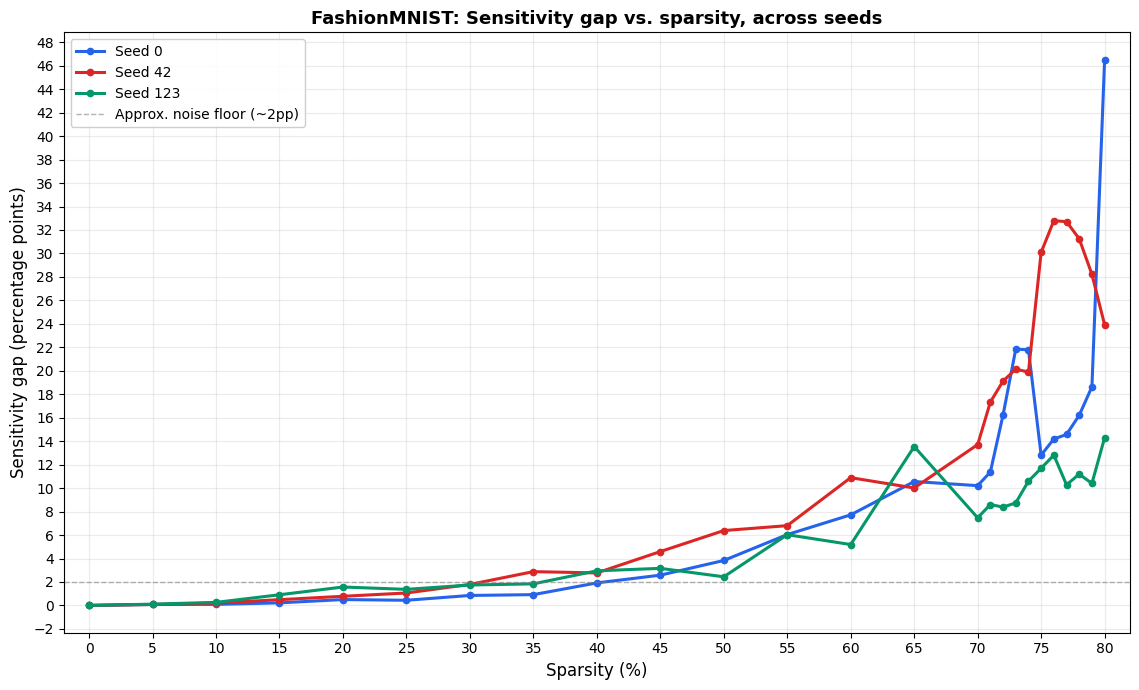

Saved: 'FashionMNIST_gap_multiseed.png


In [13]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator 
fig, ax = plt.subplots(figsize=(11.5, 7))
 
colors = {0: '#2563EB', 42: '#DC2626', 123: '#059669'}
 
for seed in SEEDS:
    gaps = [results[seed][pct] for pct in CHECKPOINTS]
    ax.plot(CHECKPOINTS, gaps, '-o', color=colors.get(seed, 'gray'),
            linewidth=2.2, markersize=4.5, label=f'Seed {seed}')
 
ax.axhline(2, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Approx. noise floor (~2pp)')
 
ax.set_xlabel('Sparsity (%)', fontsize=12)
ax.set_ylabel('Sensitivity gap (percentage points)', fontsize=12)
ax.set_title('FashionMNIST: Sensitivity gap vs. sparsity, across seeds', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.25)
ax.set_xlim(min(CHECKPOINTS) - 2, max(CHECKPOINTS) + 2)
ax.xaxis.set_major_locator(MultipleLocator(5))    # x-axis ticks every 5% instead of every 10%
ax.yaxis.set_major_locator(MultipleLocator(2)) 
plt.tight_layout()
plt.savefig('FashionMNIST_gap_multiseed.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: 'FashionMNIST_gap_multiseed.png")

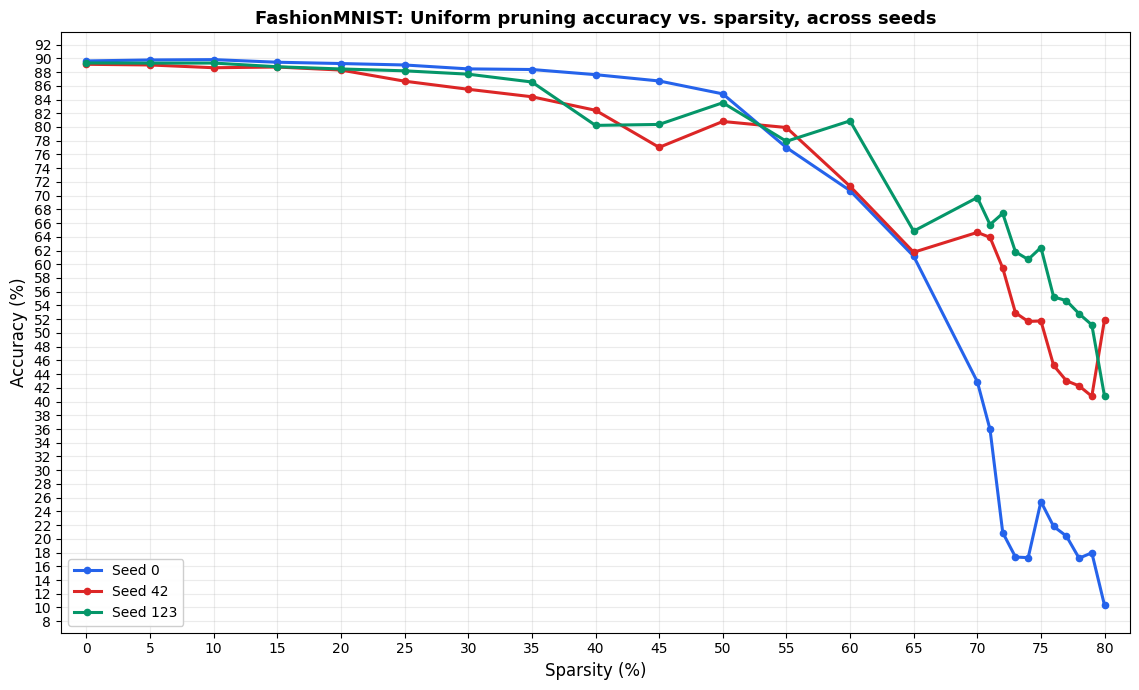

Saved: 'FashionMNIST_uniform_accuracy_multiseed.png


In [15]:
# ============================================================
# GRAPH 2 — Accuracy vs sparsity (uniform pruning), across seeds
# Uses `uniform_results` (from your uniform pruning sweep cell)
# ============================================================
fig, ax = plt.subplots(figsize=(11.5, 7))
 
for seed in SEEDS:
    accs = [uniform_results[seed][pct] for pct in CHECKPOINTS]
    ax.plot(CHECKPOINTS, accs, '-o', color=colors.get(seed, 'gray'),
            linewidth=2.2, markersize=4.5, label=f'Seed {seed}')
 
ax.set_xlabel('Sparsity (%)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('FashionMNIST: Uniform pruning accuracy vs. sparsity, across seeds', fontsize=13, fontweight='bold')
ax.legend(loc='lower left', fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.25)
ax.set_xlim(min(CHECKPOINTS) - 2, max(CHECKPOINTS) + 2)
ax.xaxis.set_major_locator(MultipleLocator(5))    # x-axis ticks every 5% instead of every 10%
ax.yaxis.set_major_locator(MultipleLocator(2)) 
plt.tight_layout()
plt.savefig('FashionMNIST_uniform_accuracy_multiseed.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: 'FashionMNIST_uniform_accuracy_multiseed.png")

In [ ]:


import ruptures as rpt
import numpy as np

def find_change_point(sparsity_values, signal_values, label=""):
    """
    Detects the point where `signal_values` (gap or accuracy) changes trend.
    Returns the sparsity value at the detected change point.
    """
    signal = np.array(signal_values)

    # PELT algorithm, "rbf" cost function — good default for detecting
    # shifts in trend/variance without assuming a specific shape in advance
    algo = rpt.Pelt(model="rbf").fit(signal)
    # penalty controls sensitivity — higher = fewer, more confident change points
    # start with 3, adjust if it finds too many/too few points
    change_points = algo.predict(pen=3)

    # change_points gives indices (not sparsity values) where the biggest
    # gets returned last as len(signal) — drop that one, keep the real point(s)
    real_points = [cp for cp in change_points if cp < len(signal)]

    print(f"\n{label}")
    if not real_points:
        print("  No significant change point detected (signal too flat/noisy)")
        return None

    for cp_idx in real_points:
        cp_sparsity = sparsity_values[cp_idx]
        print(f"  Change point at index {cp_idx} → sparsity ≈ {cp_sparsity}%")

    # Return the FIRST detected change point — this is usually the one
    # that matters for "departure from baseline behavior"
    first_cp_sparsity = sparsity_values[real_points[0]]
    return first_cp_sparsity


# ============================================================
# USAGE — run this for each seed, both gap and accuracy
# ============================================================

CHECKPOINTS = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80]

for seed in SEEDS:
    gap_values = [results[seed][pct] for pct in CHECKPOINTS]
    acc_values = [uniform_results[seed][pct] for pct in CHECKPOINTS]

    gap_cp = find_change_point(CHECKPOINTS, gap_values, label=f"Seed {seed} — GAP change point")
    acc_cp = find_change_point(CHECKPOINTS, acc_values, label=f"Seed {seed} — ACCURACY change point")

    if gap_cp is not None and acc_cp is not None:
        lead = acc_cp - gap_cp
        print(f"  --> Seed {seed} lead time: {lead}pp (gap changes at {gap_cp}%, accuracy changes at {acc_cp}%)")


Seed 0 — GAP change point
  Change point at index 10 → sparsity ≈ 50%

Seed 0 — ACCURACY change point
  Change point at index 15 → sparsity ≈ 71%
  --> Seed 0 lead time: 21pp (gap changes at 50%, accuracy changes at 71%)

Seed 42 — GAP change point
  Change point at index 15 → sparsity ≈ 71%

Seed 42 — ACCURACY change point
  Change point at index 15 → sparsity ≈ 71%
  --> Seed 42 lead time: 0pp (gap changes at 71%, accuracy changes at 71%)

Seed 123 — GAP change point
  Change point at index 10 → sparsity ≈ 50%

Seed 123 — ACCURACY change point
  Change point at index 15 → sparsity ≈ 71%
  --> Seed 123 lead time: 21pp (gap changes at 50%, accuracy changes at 71%)



Seed 0 — GAP change point
  Change point at sparsity ≈ 50%

Seed 0 — ACCURACY change point
  Change point at sparsity ≈ 71%
  --> Seed 0 lead time: 21pp


Seed 42 — GAP change point
  Change point at sparsity ≈ 71%

Seed 42 — ACCURACY change point
  Change point at sparsity ≈ 71%
  --> Seed 42 lead time: 0pp


Seed 123 — GAP change point
  Change point at sparsity ≈ 50%

Seed 123 — ACCURACY change point
  Change point at sparsity ≈ 71%
  --> Seed 123 lead time: 21pp



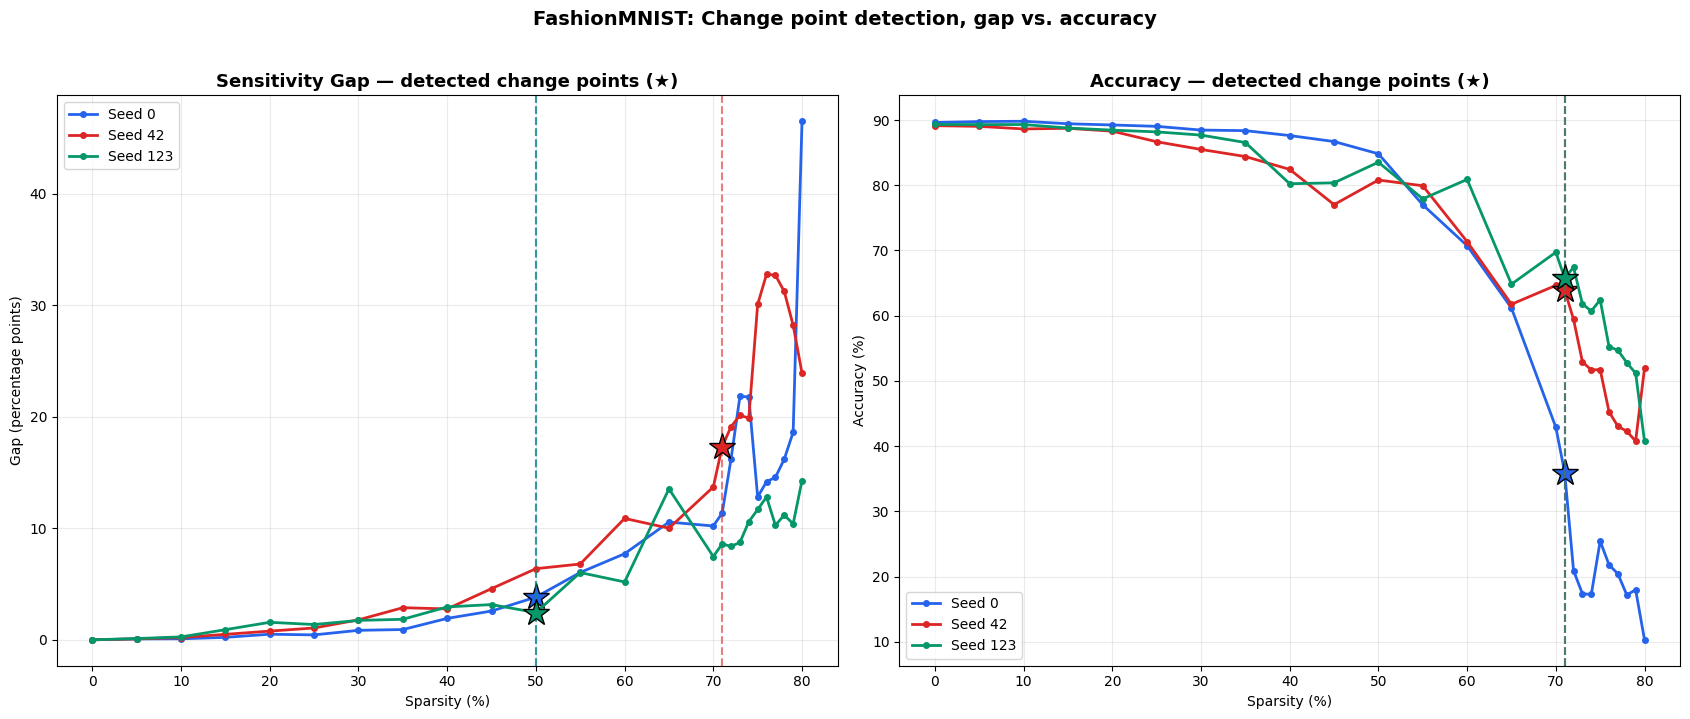


=== SUMMARY: lead times from change point detection ===
Seed 0: 21pp lead
Seed 42: 0pp lead
Seed 123: 21pp lead


In [17]:
# ============================================================
# CHANGE POINT DETECTION + GRAPH
# ============================================================

import ruptures as rpt
import numpy as np
import matplotlib.pyplot as plt

def find_change_point(sparsity_values, signal_values, label=""):
    signal = np.array(signal_values)
    algo = rpt.Pelt(model="rbf").fit(signal)
    change_points = algo.predict(pen=3)
    real_points = [cp for cp in change_points if cp < len(signal)]

    print(f"\n{label}")
    if not real_points:
        print("  No significant change point detected")
        return None

    for cp_idx in real_points:
        print(f"  Change point at sparsity ≈ {sparsity_values[cp_idx]}%")

    return sparsity_values[real_points[0]]  # first detected change point


CHECKPOINTS = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80]
colors = {0: '#2563EB', 42: '#DC2626', 123: '#059669'}

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
ax_gap, ax_acc = axes

lead_times = {}

for seed in SEEDS:
    gap_values = [results[seed][pct] for pct in CHECKPOINTS]
    acc_values = [uniform_results[seed][pct] for pct in CHECKPOINTS]

    gap_cp = find_change_point(CHECKPOINTS, gap_values, label=f"Seed {seed} — GAP change point")
    acc_cp = find_change_point(CHECKPOINTS, acc_values, label=f"Seed {seed} — ACCURACY change point")

    if gap_cp is not None and acc_cp is not None:
        lead = acc_cp - gap_cp
        lead_times[seed] = lead
        print(f"  --> Seed {seed} lead time: {lead}pp\n")

    color = colors[seed]

    # Plot gap curve + mark its change point
    ax_gap.plot(CHECKPOINTS, gap_values, '-o', color=color, linewidth=2, markersize=4, label=f'Seed {seed}')
    if gap_cp is not None:
        ax_gap.axvline(gap_cp, color=color, linestyle='--', alpha=0.6)
        ax_gap.plot(gap_cp, gap_values[CHECKPOINTS.index(gap_cp)], '*', color=color, markersize=20, markeredgecolor='black')

    # Plot accuracy curve + mark its change point
    ax_acc.plot(CHECKPOINTS, acc_values, '-o', color=color, linewidth=2, markersize=4, label=f'Seed {seed}')
    if acc_cp is not None:
        ax_acc.axvline(acc_cp, color=color, linestyle='--', alpha=0.6)
        ax_acc.plot(acc_cp, acc_values[CHECKPOINTS.index(acc_cp)], '*', color=color, markersize=20, markeredgecolor='black')

ax_gap.set_title('Sensitivity Gap — detected change points (★)', fontsize=13, fontweight='bold')
ax_gap.set_xlabel('Sparsity (%)')
ax_gap.set_ylabel('Gap (percentage points)')
ax_gap.legend()
ax_gap.grid(True, alpha=0.25)

ax_acc.set_title('Accuracy — detected change points (★)', fontsize=13, fontweight='bold')
ax_acc.set_xlabel('Sparsity (%)')
ax_acc.set_ylabel('Accuracy (%)')
ax_acc.legend()
ax_acc.grid(True, alpha=0.25)

plt.suptitle('FashionMNIST: Change point detection, gap vs. accuracy', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fashionmnist_changepoint.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n=== SUMMARY: lead times from change point detection ===")
for seed, lead in lead_times.items():
    print(f"Seed {seed}: {lead}pp lead")

In [19]:
# ============================================================
# THREE-METHOD CHANGE POINT COMPARISON: PELT, CUSUM, BOCPD
# Run this AFTER your results/uniform_results already exist.
#
# Install first (terminal or !pip in a cell):
#   pip install ruptures bayesian_changepoint_detection --break-system-packages
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import ruptures as rpt

CHECKPOINTS = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80]
colors = {0: '#2563EB', 42: '#DC2626', 123: '#059669'}

# ------------------------------------------------------------
# METHOD 1 — PELT (already built, kept here for comparison)
# ------------------------------------------------------------
def pelt_change_point(signal_values, sparsity_values, pen=3):
    signal = np.array(signal_values)
    algo = rpt.Pelt(model="rbf").fit(signal)
    cps = algo.predict(pen=pen)
    real = [cp for cp in cps if cp < len(signal)]
    return sparsity_values[real[0]] if real else None


# ------------------------------------------------------------
# METHOD 2 — CUSUM (Cumulative Sum)
# Simple, classic method: tracks the running cumulative deviation
# from the mean of an initial "baseline" window. Flags the point
# where that cumulative sum first crosses a threshold — i.e.,
# where the signal has drifted meaningfully and consistently
# away from its early baseline behavior.
# ------------------------------------------------------------
def cusum_change_point(signal_values, sparsity_values, baseline_window=4, threshold_std=3):
    signal = np.array(signal_values)
    baseline_mean = signal[:baseline_window].mean()
    baseline_std = signal[:baseline_window].std() + 1e-6  # avoid divide-by-zero

    cumsum = 0
    for i, val in enumerate(signal):
        cumsum += (val - baseline_mean)
        # threshold scaled by baseline noise level
        if abs(cumsum) > threshold_std * baseline_std:
            return sparsity_values[i]
    return None  # never crossed threshold


# ------------------------------------------------------------
# METHOD 3 — BOCPD (Bayesian Online Change Point Detection)
# Probabilistic method: at each point, estimates the probability
# that a "new regime" has started, given everything seen so far.
# More principled than a fixed threshold, but needs a library.
# ------------------------------------------------------------
try:
    from bayesian_changepoint_detection.online_changepoint_detection import online_changepoint_detection
    from bayesian_changepoint_detection.hazard_functions import constant_hazard
    from functools import partial
    import bayesian_changepoint_detection.online_likelihoods as online_ll

    def bocpd_change_point(signal_values, sparsity_values):
        signal = np.array(signal_values)
        hazard = partial(constant_hazard, 250)  # expected run length ~250 steps (tune-able)
        likelihood = online_ll.StudentT(alpha=0.1, beta=0.01, kappa=1, mu=0)
        R, maxes = online_changepoint_detection(signal, hazard, likelihood)
        # maxes[i] = the algorithm's best guess of "how long since the last change point" at step i
        # A change point is where this run-length estimate resets to near-zero
        run_lengths = maxes[1:]
        for i in range(1, len(run_lengths)):
            if run_lengths[i] < run_lengths[i-1] - 2:  # sudden reset in run length
                return sparsity_values[i]
        return None

    BOCPD_AVAILABLE = True
except ImportError:
    BOCPD_AVAILABLE = False
    print("bayesian_changepoint_detection not installed — BOCPD will be skipped.")
    print("Install with: pip install bayesian_changepoint_detection --break-system-packages")


# ============================================================
# RUN ALL THREE METHODS, ALL SEEDS, GAP + ACCURACY
# ============================================================
print("="*70)
print("COMPARISON: PELT vs CUSUM vs BOCPD")
print("="*70)

all_results = {}

for seed in SEEDS:
    gap_values = [results[seed][pct] for pct in CHECKPOINTS]
    acc_values = [uniform_results[seed][pct] for pct in CHECKPOINTS]

    print(f"\n--- Seed {seed} ---")

    gap_pelt = pelt_change_point(gap_values, CHECKPOINTS)
    gap_cusum = cusum_change_point(gap_values, CHECKPOINTS)
    gap_bocpd = bocpd_change_point(gap_values, CHECKPOINTS) if BOCPD_AVAILABLE else None

    acc_pelt = pelt_change_point(acc_values, CHECKPOINTS)
    acc_cusum = cusum_change_point(acc_values, CHECKPOINTS)
    acc_bocpd = bocpd_change_point(acc_values, CHECKPOINTS) if BOCPD_AVAILABLE else None

    print(f"  GAP      change point — PELT: {gap_pelt}%  | CUSUM: {gap_cusum}%  | BOCPD: {gap_bocpd}%")
    print(f"  ACCURACY change point — PELT: {acc_pelt}%  | CUSUM: {acc_cusum}%  | BOCPD: {acc_bocpd}%")

    for method, gap_cp, acc_cp in [("PELT", gap_pelt, acc_pelt), ("CUSUM", gap_cusum, acc_cusum), ("BOCPD", gap_bocpd, acc_bocpd)]:
        if gap_cp is not None and acc_cp is not None:
            print(f"    --> {method} lead time: {acc_cp - gap_cp}pp")

    all_results[seed] = {
        'gap': {'PELT': gap_pelt, 'CUSUM': gap_cusum, 'BOCPD': gap_bocpd},
        'acc': {'PELT': acc_pelt, 'CUSUM': acc_cusum, 'BOCPD': acc_bocpd}
    }

print("\n" + "="*70)
print("If PELT, CUSUM, and BOCPD roughly agree on a seed's change point,")
print("that's a much more trustworthy number than any single method alone.")
print("If they disagree a lot, that itself is worth reporting honestly —")
print("it means the 'departure point' is genuinely ambiguous for that curve.")
print("="*70)

bayesian_changepoint_detection not installed — BOCPD will be skipped.
Install with: pip install bayesian_changepoint_detection --break-system-packages
COMPARISON: PELT vs CUSUM vs BOCPD

--- Seed 0 ---
  GAP      change point — PELT: 50%  | CUSUM: 20%  | BOCPD: None%
  ACCURACY change point — PELT: 71%  | CUSUM: 25%  | BOCPD: None%
    --> PELT lead time: 21pp
    --> CUSUM lead time: 5pp

--- Seed 42 ---
  GAP      change point — PELT: 71%  | CUSUM: 20%  | BOCPD: None%
  ACCURACY change point — PELT: 71%  | CUSUM: 25%  | BOCPD: None%
    --> PELT lead time: 0pp
    --> CUSUM lead time: 5pp

--- Seed 123 ---
  GAP      change point — PELT: 50%  | CUSUM: 20%  | BOCPD: None%
  ACCURACY change point — PELT: 71%  | CUSUM: 20%  | BOCPD: None%
    --> PELT lead time: 21pp
    --> CUSUM lead time: 0pp

If PELT, CUSUM, and BOCPD roughly agree on a seed's change point,
that's a much more trustworthy number than any single method alone.
If they disagree a lot, that itself is worth reporting hone

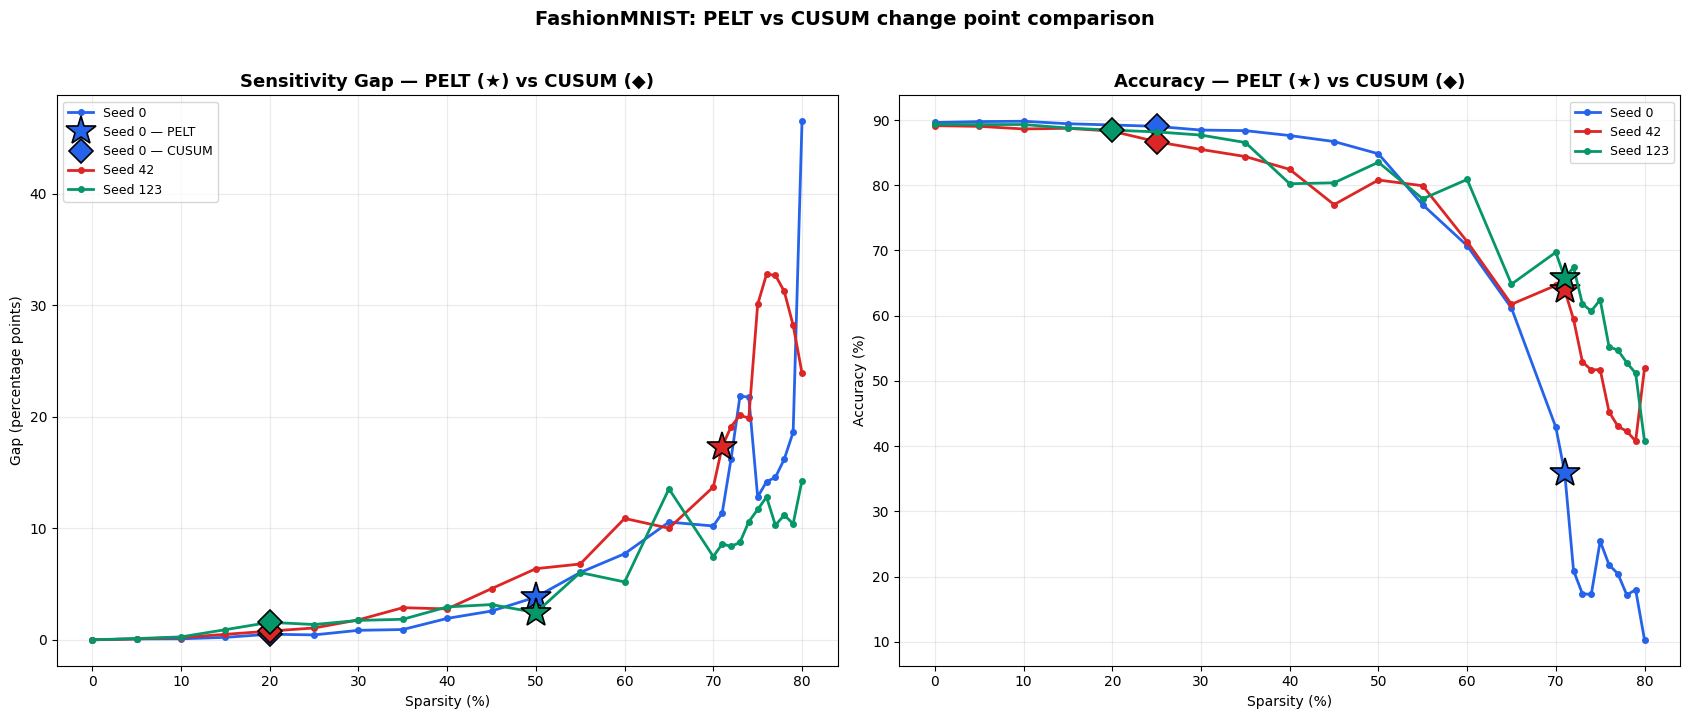

Saved: fashionmnist_pelt_vs_cusum.png


In [20]:
 
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
ax_gap, ax_acc = axes
 
method_markers = {'PELT': ('*', 22), 'CUSUM': ('D', 12)}  # star for PELT, diamond for CUSUM
 
for seed in SEEDS:
    gap_values = [results[seed][pct] for pct in CHECKPOINTS]
    acc_values = [uniform_results[seed][pct] for pct in CHECKPOINTS]
    color = colors[seed]
 
    ax_gap.plot(CHECKPOINTS, gap_values, '-o', color=color, linewidth=2, markersize=4, label=f'Seed {seed}')
    ax_acc.plot(CHECKPOINTS, acc_values, '-o', color=color, linewidth=2, markersize=4, label=f'Seed {seed}')
 
    for method in ['PELT', 'CUSUM']:
        marker, size = method_markers[method]
 
        gap_cp = all_results[seed]['gap'][method]
        if gap_cp is not None:
            idx = CHECKPOINTS.index(gap_cp)
            ax_gap.plot(gap_cp, gap_values[idx], marker, color=color, markersize=size,
                        markeredgecolor='black', markeredgewidth=1.2,
                        label=f'Seed {seed} — {method}' if seed == SEEDS[0] else None)
 
        acc_cp = all_results[seed]['acc'][method]
        if acc_cp is not None:
            idx = CHECKPOINTS.index(acc_cp)
            ax_acc.plot(acc_cp, acc_values[idx], marker, color=color, markersize=size,
                        markeredgecolor='black', markeredgewidth=1.2)
 
ax_gap.set_title('Sensitivity Gap — PELT (★) vs CUSUM (◆)', fontsize=13, fontweight='bold')
ax_gap.set_xlabel('Sparsity (%)')
ax_gap.set_ylabel('Gap (percentage points)')
ax_gap.legend(fontsize=9)
ax_gap.grid(True, alpha=0.25)
 
ax_acc.set_title('Accuracy — PELT (★) vs CUSUM (◆)', fontsize=13, fontweight='bold')
ax_acc.set_xlabel('Sparsity (%)')
ax_acc.set_ylabel('Accuracy (%)')
ax_acc.legend(fontsize=9)
ax_acc.grid(True, alpha=0.25)
 
plt.suptitle('FashionMNIST: PELT vs CUSUM change point comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fashionmnist_pelt_vs_cusum.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: fashionmnist_pelt_vs_cusum.png")